In [1]:
from data_utils.ABC_dataset import ABCDataset, get_item
import numpy as np
import matplotlib.pyplot as plt
import utils.mesh_tools as mt
import igl
from meshplot import plot
import fvdb
import fvdb.nn as fvnn
import torch
import torch.nn as nn
from tqdm import tqdm

In [2]:
device='cuda'

In [3]:
src_dir = "../data/groundtruth/gt_NMC/"
with open('data_utils/abc_watertight_train.txt', 'r') as f:
    train_set_names = [e[:-1] for e in f.readlines()]

In [ ]:
# TODO: move some of these functions to ABC_dataset
def vdb_marching_cubes(out: fvnn.VDBTensor):
    '''computes marching cubes for a VDBTensor'''
    nv, nf, _ = out.grid.marching_cubes(out.data)
    return nv.jdata.cpu().detach().numpy(), nf.jdata.cpu().detach().numpy()

def fetch_numpy_values(grid: fvdb.GridBatch, arr: np.array, size:int):
    '''fetches values from a numpy array based on the ijk indices in the grid'''
    ijk = grid.ijk.jdata.cpu().detach().numpy()+(size-1)//2
    values = arr[ijk[:, 0], ijk[:, 1], ijk[:, 2]]
    return torch.tensor(values, dtype=torch.float32, device=grid.device)
    
def sdf_to_vdb(sdf_grid, large_sdf_grid, mask, size=33):
    '''takes SDF pair grids and a mask, returns small and large VDBTensors. SDF values scaled by size'''
    ijk_mesh_grid = mt.mesh_grid(size)
    ijk_mesh_grid = ijk_mesh_grid.reshape(size, size, size, 3)
    ijk = torch.tensor(ijk_mesh_grid[mask], dtype=torch.int, device=device)-(size-1)//2
    grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(ijk), voxel_sizes=(1/(size-1)), origins=torch.tensor([0, 0, 0], device=device))
    sdf_values = fetch_numpy_values(grid, sdf_grid, size)
    small_vdb = fvnn.VDBTensor(grid, grid.jagged_like((size-1)*sdf_values[:, None]))
    
    # extract large sdf grid
    big_vdb_grid = custom_subdivide_grid(small_vdb.grid)
    sdf_values = fetch_numpy_values(big_vdb_grid, large_sdf_grid, 2*size-1)
    large_vdb = fvnn.VDBTensor(big_vdb_grid, big_vdb_grid.jagged_like((size-1)*sdf_values[:, None]))

    return small_vdb, large_vdb

def custom_subdivide_grid(grid: fvdb.GridBatch):
    '''custom subdivision of a grid to create a finer grid:
        [0,    1,    2] -->
        [0, 1, 2, 3, 4]'''
    ijk = grid.ijk.jdata
    m3g = torch.tensor(mt.mesh_grid(3),device=device)-1
    new_ijk = (2*ijk[:, None, :]+ m3g[None, :, :]).view(-1, 3)
    return fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(new_ijk), origins=grid.origins, voxel_sizes=grid.voxel_sizes/2)

In [6]:
### load whole dataset
# load_dataset = ABCDataset(src_dir, train_set_names[:50])

### load single shape
small_sdf, large_sdf = get_item(src_dir, train_set_names[0])
mt.plotSlice(small_sdf, 0.1)

interactive(children=(IntSlider(value=16, description='s', max=32), Output()), _dom_classes=('widget-interact'…

<function utils.mesh_tools.plotSlice.<locals>.<lambda>(s)>

In [8]:
def make_mask_close(sdf_input, grid_n):
    # dense grid--> sparse grid
    mask = np.abs(sdf_input) < (1/grid_n*np.sqrt(3))
    return mask


mask = make_mask_close(small_sdf, 33)
big_mask = mask.repeat(2, 0).repeat(2, 1).repeat(2, 2)
mt.plotSlice(small_sdf*mask, 0.1)

interactive(children=(IntSlider(value=16, description='s', max=32), Output()), _dom_classes=('widget-interact'…

<function utils.mesh_tools.plotSlice.<locals>.<lambda>(s)>

In [10]:
### GET VDB tensor
small_vdb, large_vdb = sdf_to_vdb(small_sdf, large_sdf.squeeze(), mask)

In [11]:
# sanity check:
indices = large_vdb.grid.ijk_to_index(small_vdb.ijk.jdata*2)
(large_vdb.data[indices].jdata-small_vdb.jdata).max()

tensor(0., device='cuda:0')

In [12]:
mt.export_obj(*vdb_marching_cubes(small_vdb), '32_vdb.obj')
mt.export_obj(*vdb_marching_cubes(large_vdb), '64_vdb.obj')

In [13]:

def positional_encoding(small_vdb, dim):
    '''helps the learning'''
    feat = small_vdb.jdata
    half_dim = dim // 2
    emb = torch.arange(
        start=0, end=half_dim, dtype=torch.float32, device=feat.device)
    emb = 2**emb * torch.pi
    emb = feat.float() * emb[None, :]
    new_feat = torch.cat([feat, emb.sin(), emb.cos()], dim=-1)
    return fvnn.VDBTensor(small_vdb.grid, small_vdb.grid.jagged_like(new_feat))
    



In [32]:

class CNN_vanilla(nn.Module):
    def __init__(self, in_channels=3, features=32, out_channels=1, dropout=0.05):
        super(CNN_vanilla, self).__init__()
        print('TODO:  \n - check that the transposed conv is correct \n - add/remove layers \n - add MaxPool to be invariant to sparse grid activations?')
        self.activation = fvnn.SiLU(inplace=True)
        self.encoder = nn.Sequential(
            fvnn.SparseConv3d(in_channels, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,

            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation
        )
        
        self.decoder = nn.Sequential(
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=1, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=1, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, out_channels, kernel_size=1, stride=1)
        )

        self.t_conv = fvnn.SparseConv3d(
            features, features, kernel_size=3, stride=2, transposed=True) #TODO check that this is correct

    def forward(self, x, out_grid):
        enc = self.encoder(x)
        x = self.t_conv(enc, out_grid=out_grid) 
        return self.decoder(x)

pos_enc_dim = 10
input_vdb = positional_encoding(small_vdb, 10)
M = CNN_vanilla(in_channels=pos_enc_dim+1, features=128, out_channels=1, dropout=0.00).to(device)
# M(small_vdb, large_vdb.grid)
M.train()
# small_vdb.data.jdata.shape

optimizer = torch.optim.Adam(M.parameters(), lr=1e-4)
L = []
def train_step(model, optimizer, input_vdb, large_vdb):
    optimizer.zero_grad()
    out = model(input_vdb, large_vdb.grid)
    loss = nn.functional.mse_loss(out.jdata, large_vdb.data.jdata)
    loss.backward()
    optimizer.step()
    return loss.item()

TODO:  
 - check that the transposed conv is correct 
 - add/remove layers 
 - add MaxPool to be invariant to sparse grid activations?


In [38]:
for i in tqdm(range(2000)):
    L.append(train_step(M, optimizer, input_vdb, large_vdb))

100%|██████████| 1000/1000 [00:13<00:00, 75.89it/s]


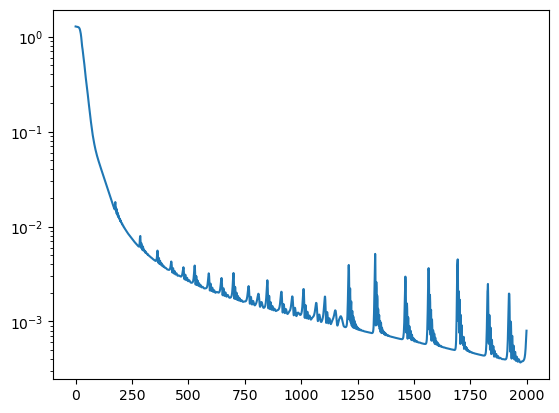

In [39]:
plt.plot(L)
plt.yscale('log')

In [40]:
large_vdb.jdata

tensor([[2.3974],
        [2.2571],
        [2.1115],
        ...,
        [2.3504],
        [2.1892],
        [2.4266]], device='cuda:0')

In [41]:
out_vdb = M(input_vdb, large_vdb.grid)
out_vdb.jdata

tensor([[2.3895],
        [2.2341],
        [2.0961],
        ...,
        [2.3128],
        [2.1557],
        [2.4103]], device='cuda:0', grad_fn=<AddBackward0>)

In [42]:
mt.export_obj(*vdb_marching_cubes(out_vdb), '64_pro.obj')